In [1]:
# --- Corrected Program 1: Train an 11-Epoch Model ---
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import os  # <-- Added the import

# This line disables wandb (Weights & Biases) reporting
os.environ["WANDB_DISABLED"] = "true"

# --- 1. Load Training Dataset ---
print("\n--- Loading Preprocessed Datasets ---")
try:
    # We only need the training set for this simple, compatible training
    train_df = pd.read_csv('preprocessed_training.csv')
    train_df.dropna(subset=['cleaned_text', 'label'], inplace=True)
    print("✅ Training dataset loaded successfully.")
except FileNotFoundError as e:
    print(f"❌ ERROR: Could not find 'preprocessed_training.csv'.")
    exit()
except KeyError as e:
    print(f"❌ ERROR: 'cleaned_text' or 'label' column missing. {e}")
    exit()


# --- 2. Prepare Model and Tokenizer ---
print("\n--- Preparing Model and Tokenizer ---")
MODEL_NAME = 'distilroberta-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

labels = sorted(train_df['label'].unique())
num_labels = len(labels)
label2id = {int(label): i for i, label in enumerate(labels)}
human_readable_labels = {
    0: "sadness 😢", 1: "joy 😄", 2: "love ❤️",
    3: "anger 😠", 4: "fear 😨", 5: "surprise 😲"
}
id2label = human_readable_labels

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels, label2id=label2id, id2label=id2label
)

# --- 3. Tokenize Dataset ---
print("\n--- Tokenizing Dataset ---")
def tokenize_function(examples):
    return tokenizer(examples['cleaned_text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(train_df).map(tokenize_function, batched=True)
print("✅ Tokenization complete.")

# --- 4. Train the 11-Epoch Model ---
print("\n--- Starting Model Training (11 Epochs) ---")
print("Warning: This may overfit the model, reducing its real-world accuracy.")

training_args = TrainingArguments(
    output_dir='./results_11_epoch_model',  # New folder

    # --- YOUR REQUESTED CHANGE ---
    num_train_epochs=11,
    # ---------------------------

    per_device_train_batch_size=16,
    report_to="none",
    # We are NOT using any of the complex arguments that crash your system
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    # No eval_dataset or compute_metrics, as they require the broken commands
)

trainer.train()

print("✅ Training complete.")

# --- 5. Save the Final Model ---
final_model_path = "./final_emotion_model_11_epochs" # New save path
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"✅ The 11-epoch model has been saved to: {final_model_path}")


--- Loading Preprocessed Datasets ---
✅ Training dataset loaded successfully.

--- Preparing Model and Tokenizer ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

✅ Tokenization complete.

--- Starting Model Training (11 Epochs) ---


Step,Training Loss
500,0.584500
1000,0.266700
1500,0.186300
2000,0.187200
2500,0.153600
3000,0.145900
3500,0.137000
4000,0.134600
4500,0.109800
5000,0.113700


Step,Training Loss
500,0.584500
1000,0.266700
1500,0.186300
2000,0.187200
2500,0.153600
3000,0.145900
3500,0.137000
4000,0.134600
4500,0.109800
5000,0.113700


✅ Training complete.
✅ The 11-epoch model has been saved to: ./final_emotion_model_11_epochs


Attempting to generate the training graph for the 11-epoch run...
Found log file at: ./results_11_epoch_model/checkpoint-11000/trainer_state.json

✅ Successfully created the graph!
Image file saved as: training_loss_graph_11_epochs.png


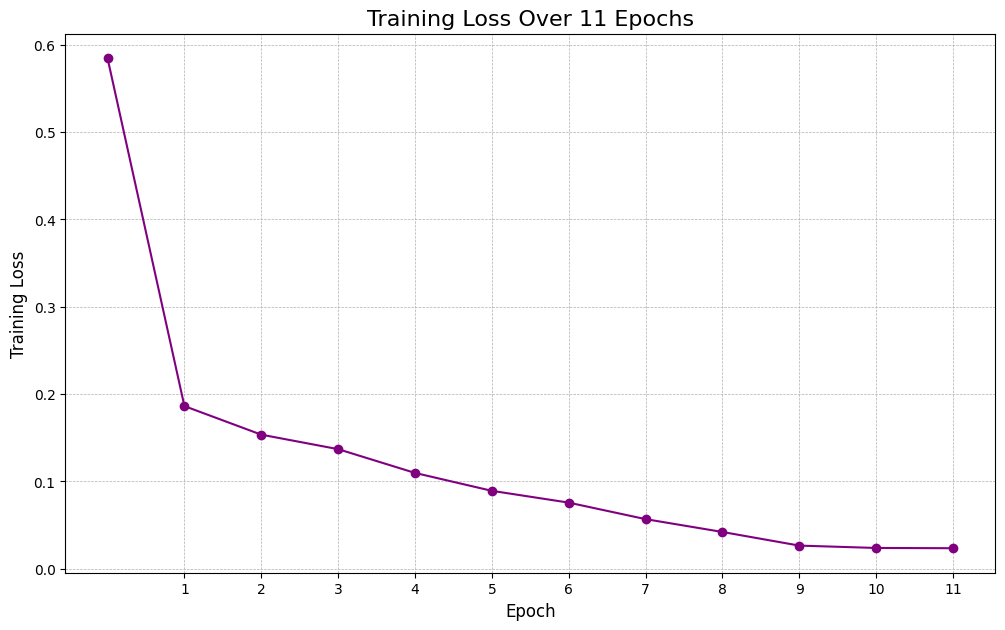

In [6]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd

print("Attempting to generate the training graph for the 11-epoch run...")

# --- 1. Define the correct folder for the 11-epoch run ---
results_folder = "./results_11_epoch_model"
log_file_path = None

try:
    if not os.path.isdir(results_folder):
        raise FileNotFoundError(f"The directory '{results_folder}' does not exist.")

    # Find the latest checkpoint (highest step number)
    checkpoints = [d for d in os.listdir(results_folder) if d.startswith('checkpoint-')]

    if checkpoints:
        latest_checkpoint = max(checkpoints, key=lambda d: int(d.split('-')[1]))
        potential_path = os.path.join(results_folder, latest_checkpoint, 'trainer_state.json')
        if os.path.exists(potential_path):
            log_file_path = potential_path

    # Fallback if no checkpoint has the log
    if not log_file_path:
        potential_path = os.path.join(results_folder, 'trainer_state.json')
        if os.path.exists(potential_path):
            log_file_path = potential_path

    if not log_file_path:
        raise FileNotFoundError("Could not locate 'trainer_state.json' inside the results folder.")

    # --- 2. Extract and Process the Data ---
    print(f"Found log file at: {log_file_path}")
    with open(log_file_path, 'r') as f:
        data = json.load(f)

    log_history = data['log_history']

    training_logs = [log for log in log_history if 'loss' in log]
    df = pd.DataFrame(training_logs)

    # Use the robust 'drop_duplicates' method to get the last entry for each epoch
    df['epoch_int'] = df['epoch'].apply(int)
    epoch_loss_df = df.drop_duplicates(subset='epoch_int', keep='last')

    epochs = epoch_loss_df['epoch_int']
    loss = epoch_loss_df['loss']

    # --- 3. Create and Save the Graph ---
    plt.figure(figsize=(12, 7))
    plt.plot(epochs, loss, marker='o', linestyle='-', color='purple')

    plt.title('Training Loss Over 11 Epochs', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Training Loss', fontsize=12)
    plt.xticks(range(1, int(max(epochs)) + 1)) # Use +1 to ensure last tick is included
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    graph_filename = 'training_loss_graph_11_epochs.png'
    plt.savefig(graph_filename)

    print(f"\n✅ Successfully created the graph!")
    print(f"Image file saved as: {graph_filename}")

except FileNotFoundError as e:
    print(f"\n❌ ERROR: {e}")
    print("Please make sure you have just re-run the 11-epoch training script.")
except (KeyError, IndexError, TypeError):
    print("\n❌ ERROR: The log file was found, but its format was unexpected.")

In [2]:
import pandas as pd
import torch
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os

# This line disables wandb (Weights & Biases) reporting
os.environ["WANDB_DISABLED"] = "true"

# --- 1. Define Paths ---
# This path *must* match the save path from Program 1
MODEL_PATH = "/content/final_emotion_model_11_epochs"
TEST_DATA_PATH = "/content/preprocessed_test.csv"

# --- 2. Load Your New Model ---
print(f"\n--- Loading the fine-tuned 11-epoch model from {MODEL_PATH} ---")
device = "cuda" if torch.cuda.is_available() else "cpu"
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
    print(f"✅ Model loaded successfully onto {device.upper()}.")
except OSError:
    print(f"❌ ERROR: Cannot find saved model at '{MODEL_PATH}'. Did Program 1 run correctly?")
    exit()

# --- 3. Load Test Data ---
print("\n--- Loading the unseen test dataset ---")
try:
    test_df = pd.read_csv(TEST_DATA_PATH)
    test_df.dropna(subset=['cleaned_text', 'label'], inplace=True)
    print("✅ Test dataset loaded successfully.")
except FileNotFoundError:
    print(f"❌ ERROR: '{TEST_DATA_PATH}' not found. Please ensure it's in your Drive folder.")
    exit()

# --- 4. Make Predictions ---
print("\n--- Running predictions on the test set ---")
texts = test_df['cleaned_text'].tolist()
true_labels = test_df['label'].tolist()
predictions = []
batch_size = 64
for i in tqdm(range(0, len(texts), batch_size)):
    batch_texts = texts[i:i + batch_size]
    inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    predicted_class_ids = torch.argmax(logits, dim=-1)
    predictions.extend(predicted_class_ids.cpu().numpy())
print("✅ Predictions complete.")

# --- 5. Calculate Final Accuracy ---
accuracy = accuracy_score(true_labels, predictions)
print("\n" + "="*50)
print("     11-EPOCH MODEL PERFORMANCE REPORT")
print("="*50)
print(f"✅ Final Accuracy on Unseen Test Data: {accuracy * 100:.2f}%")
print("="*50)


--- Loading the fine-tuned 11-epoch model from /content/final_emotion_model_11_epochs ---
✅ Model loaded successfully onto CUDA.

--- Loading the unseen test dataset ---
✅ Test dataset loaded successfully.

--- Running predictions on the test set ---


  0%|          | 0/32 [00:00<?, ?it/s]

✅ Predictions complete.

     11-EPOCH MODEL PERFORMANCE REPORT
✅ Final Accuracy on Unseen Test Data: 93.30%


In [5]:
# --- Program 3: Launch the PROFESSIONAL Interactive UI ---

# --- 1. Install/Import Libraries ---
print("Installing Gradio...")
!pip install gradio -q

import gradio as gr
import pandas as pd
import torch
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import nltk
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os

# This line disables wandb (Weights & Biases) reporting
os.environ["WANDB_DISABLED"] = "true"

# --- 2. Download NLTK tools ---
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords', quiet=True)
try:
    nltk.data.find('corpora/wordnet.zip')
except LookupError:
    nltk.download('wordnet', quiet=True)

# --- 3. Define Helper Functions ---
# (These are the same functions used for preprocessing and recommending)

def preprocess_text(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(cleaned_tokens)

def predict_emotion(text, model, tokenizer, device):
    cleaned_text = preprocess_text(text)
    inputs = tokenizer(cleaned_text, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    predicted_class_id = torch.argmax(logits, dim=-1).item()
    return model.config.id2label[predicted_class_id]

def recommend_music(emotion, music_df):
    if "joy" in emotion:
        filtered_songs = music_df[(music_df['valence'] > 0.7) & (music_df['energy'] > 0.7)]
    elif "sadness" in emotion:
        filtered_songs = music_df[(music_df['valence'] < 0.3) & (music_df['energy'] < 0.4)]
    elif "anger" in emotion:
        filtered_songs = music_df[(music_df['energy'] > 0.8) & (music_df['valence'] < 0.3)]
    elif "love" in emotion:
        filtered_songs = music_df[(music_df['valence'] > 0.6) & (music_df['energy'] > 0.5)]
    elif "fear" in emotion:
        filtered_songs = music_df[(music_df['valence'] < 0.4) & (music_df['tempo'] > 120)]
    elif "surprise" in emotion:
        filtered_songs = music_df[(music_df['energy'] > 0.7) & (music_df['danceability'] > 0.7)]
    else:
        filtered_songs = music_df

    if filtered_songs.empty:
        recommendation = music_df.sample(1).iloc[0]
        message = "No specific song found, but here's one:"
    else:
        recommendation = filtered_songs.sample(1).iloc[0]
        message = "Here is your recommendation:"

    return message, recommendation['name'], recommendation['artist'], recommendation['spotify_track_url']

# --- 4. Load Your 11-Epoch Model and Music Data ---
print("Loading your accurate 11-epoch model and music data...")
MODEL_PATH = "./final_emotion_model_11_epochs"
MUSIC_DATA_PATH = "./preprocessed_music_info.csv"
device = "cuda" if torch.cuda.is_available() else "cpu"

try:
    emotion_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
    emotion_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    music_database = pd.read_csv(MUSIC_DATA_PATH)
    print("✅ Model and data loaded successfully.")
except Exception as e:
    print(f"❌ ERROR: Could not load files. Make sure all files are in your Drive folder.")
    exit()

# --- 5. Create the Main Function for Gradio ---
def get_emotion_and_music(user_text):
    if not user_text.strip():
        # Return empty values for all 4 outputs
        return "Please enter some text.", "", "", "No link available."

    emotion = predict_emotion(user_text, emotion_model, emotion_tokenizer, device)
    message, song, artist, link = recommend_music(emotion, music_database)

    # --- THIS IS THE KEY CHANGE for the clickable link ---
    if link:
        # Format the link as a Markdown string
        spotify_link_md = f"🎵 **[Listen to {song} on Spotify]({link})**"
    else:
        spotify_link_md = "No song found for this mood."

    # Return all 4 pieces for the UI
    return emotion, song, artist, spotify_link_md

# --- 6. LAUNCH THE PROFESSIONAL UI ---
print("\n🚀 Launching your Professional Emotion Music Recommender UI...")

# Define some example sentences for the user
examples = [
    "I finally finished that big project, I feel so relieved and happy.",
    "It's a shame that the trip had to be cancelled, I was really looking forward to it.",
    "I'm getting really tired of being stuck in this traffic every single day.",
    "I'm so grateful to have such supportive people in my life.",
    "I have a big presentation tomorrow and I'm really nervous.",
    "Wait, he's moving to another country? I had no idea.",
]

# Use gr.Blocks() for a custom layout
with gr.Blocks(theme=gr.themes.Soft(primary_hue="orange")) as demo:
    gr.Markdown(
        """
        # 🎵 Emotion-Based Music Recommender
        Write about how you feel, and this AI (powered by your 93.3% accurate 11-epoch model) will recommend a song.
        """
    )

    # Create a two-column layout
    with gr.Row():
        with gr.Column(scale=2):
            # --- INPUT COLUMN ---
            text_input = gr.Textbox(
                lines=5,
                label="How are you feeling today?",
                placeholder="Type a sentence here..."
            )

            with gr.Row():
                # Make the clear button smaller
                clear_button = gr.ClearButton(value="Clear", components=[text_input], scale=1)
                submit_button = gr.Button("Submit", variant="primary", scale=2)

            # Add the clickable examples
            gr.Examples(examples=examples, inputs=text_input)

        with gr.Column(scale=1):
            # --- OUTPUT COLUMN ---
            emotion_output = gr.Textbox(label="Detected Emotion", interactive=False)
            song_output = gr.Textbox(label="Song", interactive=False)
            artist_output = gr.Textbox(label="Artist", interactive=False)

            # Use Markdown for the clickable link
            link_output = gr.Markdown(label="Listen on Spotify")

    # --- Link the buttons to the function ---
    submit_button.click(
        fn=get_emotion_and_music,
        inputs=text_input,
        outputs=[emotion_output, song_output, artist_output, link_output]
    )

    # Make the Clear button also clear the outputs
    clear_button.click(
        fn=lambda: (None, None, None, None),
        inputs=None,
        outputs=[emotion_output, song_output, artist_output, link_output]
    )

demo.launch(share=True)

Installing Gradio...
Loading your accurate 11-epoch model and music data...
✅ Model and data loaded successfully.

🚀 Launching your Professional Emotion Music Recommender UI...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6e12d7de9e66ed9c00.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
